In [ ]:
!pip -q install pandas numpy scikit-learn joblib

In [ ]:
import pandas as pd

df = pd.read_csv("profiles.csv", engine="python")
print("Shape:", df.shape)
df.head(3)


Shape: (59946, 31)


,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available


In [ ]:
df.columns
df.head(2)
df.isna().sum().sort_values(ascending=False).head(15)


,0
offspring,35561
diet,24395
religion,20226
pets,19921
essay8,19225
drugs,14080
essay6,13771
essay9,12603
essay7,12451
essay3,11476


In [ ]:
import pandas as pd

df = pd.read_csv("profiles.csv")

KEEP = [
    "age","body_type","diet","drinks","education","job","location",
    "offspring","pets","religion","sex","smokes","speaks","status"
]

# keep only those that exist
KEEP = [c for c in KEEP if c in df.columns]

df2 = df[KEEP].copy()
print("Using columns:", df2.columns.tolist())
print("Shape:", df2.shape)
df2.head(3)


Using columns: ['age', 'body_type', 'diet', 'drinks', 'education', 'job', 'location', 'offspring', 'pets', 'religion', 'sex', 'smokes', 'speaks', 'status']
Shape: (59946, 14)


,age,body_type,diet,drinks,education,job,location,offspring,pets,religion,sex,smokes,speaks,status
0,22,a little extra,strictly anything,socially,working on college/university,transportation,"south san francisco, california","doesn&rsquo;t have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,m,sometimes,english,single
1,35,average,mostly other,often,working on space camp,hospitality / travel,"oakland, california","doesn&rsquo;t have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,m,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,graduated from masters program,NaN,"san francisco, california",NaN,has cats,NaN,m,no,"english, french, c++",available


In [ ]:
import html

df2["age"] = pd.to_numeric(df2["age"], errors="coerce")
df2 = df2[(df2["age"] >= 18) & (df2["age"] <= 70)]
df2["age"] = df2["age"].fillna(df2["age"].median())

cat_cols = [c for c in df2.columns if c != "age"]

for c in cat_cols:
    df2[c] = df2[c].astype(str).apply(html.unescape).str.lower().str.strip()
    df2[c] = df2[c].replace({"nan":"unknown","none":"unknown","":"unknown"}).fillna("unknown")

df2.head(3)


,age,body_type,diet,drinks,education,job,location,offspring,pets,religion,sex,smokes,speaks,status
0,22,a little extra,strictly anything,socially,working on college/university,transportation,"south san francisco, california","doesn’t have kids, but might want them",likes dogs and likes cats,agnosticism and very serious about it,m,sometimes,english,single
1,35,average,mostly other,often,working on space camp,hospitality / travel,"oakland, california","doesn’t have kids, but might want them",likes dogs and likes cats,agnosticism but not too serious about it,m,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,graduated from masters program,unknown,"san francisco, california",unknown,has cats,unknown,m,no,"english, french, c++",available


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

X = preprocess.fit_transform(df2)
print("X shape:", X.shape)


X shape: (59944, 8033)


In [ ]:
indices_hybrid_base = indices
distances_hybrid_base = distances


In [ ]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=51, metric="cosine", algorithm="brute")
nn.fit(X)

distances, indices = nn.kneighbors(X)
print(distances.shape, indices.shape)


(59944, 51) (59944, 51)


In [ ]:
import numpy as np

def recommend_similar(user_index, top_n=10):
    neigh_idx = indices[user_index][1: top_n+1]      # skip itself at [0]
    neigh_dist = distances[user_index][1: top_n+1]
    # convert cosine distance to similarity
    return [(int(i), float(1 - d)) for i, d in zip(neigh_idx, neigh_dist)]

recommend_similar(0, top_n=5)


[(21091, 0.654248814401485),
 (34509, 0.654248814401485),
 (27001, 0.6478536438659822),
 (51036, 0.6447173242228018),
 (38084, 0.6368355631353876)]

In [ ]:
def preference_score(A, B):
    score = 0

    # age closeness
    if abs(A["age"] - B["age"]) <= 5:
        score += 1

    # religion match (if known)
    if A["religion"] != "unknown" and A["religion"] == B["religion"]:
        score += 1

    # same location
    if A["location"] != "unknown" and A["location"] == B["location"]:
        score += 1

    # education match
    if A["education"] != "unknown" and A["education"] == B["education"]:
        score += 1

    # lifestyle alignment
    if A["smokes"] == B["smokes"]:
        score += 1
    if A["drinks"] == B["drinks"]:
        score += 1

    # children preference alignment
    if A["offspring"] != "unknown" and A["offspring"] == B["offspring"]:
        score += 1

    return score

def reciprocal_recommendations(user_index, top_n=10, threshold=3):
    A = df2.iloc[user_index]
    candidates = indices[user_index][1:]  # 50 candidates

    scored = []
    for j in candidates:
        B = df2.iloc[j]
        s_ab = preference_score(A, B)
        s_ba = preference_score(B, A)
        rec = min(s_ab, s_ba)  # reciprocal
        sim = 1 - float(distances[user_index][list(indices[user_index]).index(j)])
        if rec >= threshold:
            scored.append((int(j), int(rec), float(sim)))

    scored.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return scored[:top_n]

pairs = reciprocal_recommendations(0, top_n=5, threshold=3)
pairs


[(51036, 5, 0.6447173242228018),
 (56141, 5, 0.626734354159554),
 (4608, 5, 0.5876114000056604),
 (5759, 5, 0.5857158763558322),
 (29549, 5, 0.5857158763558322)]

In [ ]:
def show_profiles(pairs):
    cols = ["age","location","religion","education","job","offspring","smokes","drinks","pets","status","sex"]
    cols = [c for c in cols if c in df2.columns]
    idxs = [p[0] for p in pairs]
    display(df2.iloc[idxs][cols])

show_profiles(pairs)


,age,location,religion,education,job,offspring,smokes,drinks,pets,status,sex
51038,23,"san francisco, california",agnosticism and laughing about it,working on college/university,other,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,single,f
56143,27,"berkeley, california",atheism,working on college/university,student,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,single,f
4609,18,"san francisco, california",atheism and laughing about it,working on college/university,student,"doesn’t have kids, but might want them",sometimes,socially,has dogs,single,m
5760,19,"hayward, california",atheism and laughing about it,working on college/university,student,"doesn’t have kids, but might want them",sometimes,socially,likes dogs,single,m
29551,19,"daly city, california",unknown,working on college/university,student,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,single,m


In [ ]:
def get_state(loc):
    parts = str(loc).split(",")
    return parts[-1].strip() if len(parts) > 1 else loc.strip()

df2["state"] = df2["location"].apply(get_state)
df2[["location", "state"]].head(5)


,location,state
0,"south san francisco, california",california
1,"oakland, california",california
2,"san francisco, california",california
3,"berkeley, california",california
4,"san francisco, california",california


In [ ]:
import re

def normalize_religion(x):
    x = str(x).lower()
    if x == "unknown":
        return "unknown"
    if "agnostic" in x:
        return "agnostic"
    if "atheis" in x:
        return "atheist"
    if "christ" in x:
        return "christian"
    if "muslim" in x or "islam" in x:
        return "muslim"
    if "hindu" in x:
        return "hindu"
    if "buddh" in x:
        return "buddhist"
    if "jew" in x:
        return "jewish"
    return "other"

df2["religion_norm"] = df2["religion"].apply(normalize_religion)
df2[["religion", "religion_norm"]].head(5)


,religion,religion_norm
0,agnosticism and very serious about it,agnostic
1,agnosticism but not too serious about it,agnostic
2,unknown,unknown
3,unknown,unknown
4,unknown,unknown


In [ ]:
def preference_score(A, B):
    score = 0

    # age closeness
    if abs(A["age"] - B["age"]) <= 5:
        score += 1

    # same state
    if A["state"] != "unknown" and A["state"] == B["state"]:
        score += 1

    # normalized religion
    if A["religion_norm"] != "unknown" and A["religion_norm"] == B["religion_norm"]:
        score += 1

    # education
    if A["education"] != "unknown" and A["education"] == B["education"]:
        score += 1

    # lifestyle
    if A["smokes"] == B["smokes"]:
        score += 1
    if A["drinks"] == B["drinks"]:
        score += 1

    # family goals
    if A["offspring"] != "unknown" and A["offspring"] == B["offspring"]:
        score += 1

    return score


In [ ]:
def reciprocal_recommendations(user_index, top_n=10, threshold=3):
    A = df2.iloc[user_index]
    candidates = indices[user_index][1:]  # 50 nearest neighbors

    scored = []
    for j in candidates:
        B = df2.iloc[j]

        # OPTIONAL: sex filter
        if A["sex"] != "unknown" and B["sex"] != "unknown" and A["sex"] == B["sex"]:
            continue

        s_ab = preference_score(A, B)
        s_ba = preference_score(B, A)
        rec = min(s_ab, s_ba)

        sim = 1 - float(distances[user_index][list(indices[user_index]).index(j)])
        if rec >= threshold:
            scored.append((int(j), int(rec), float(sim)))

    scored.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return scored[:top_n]


In [ ]:
pairs = reciprocal_recommendations(0, top_n=5, threshold=3)
pairs


[(51036, 7, 0.6447173242228018),
 (56141, 6, 0.626734354159554),
 (21488, 5, 0.5876114000056604)]

In [ ]:
def show_profiles(pairs):
    cols = ["age","location","state","religion_norm","education","job",
            "offspring","smokes","drinks","pets","status","sex"]
    cols = [c for c in cols if c in df2.columns]
    idxs = [p[0] for p in pairs]
    display(df2.iloc[idxs][cols])

show_profiles(pairs)


,age,location,state,religion_norm,education,job,offspring,smokes,drinks,pets,status,sex
51038,23,"san francisco, california",california,agnostic,working on college/university,other,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,single,f
56143,27,"berkeley, california",california,atheist,working on college/university,student,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,single,f
21489,18,"san francisco, california",california,atheist,working on college/university,student,doesn’t have kids,sometimes,socially,likes dogs and likes cats,single,f


In [ ]:
!pip -q install nltk


In [ ]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re, html

def preprocess_text(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

# Combine all essay columns first (as you did before)
essay_cols = [c for c in df.columns if c.startswith("essay")]
df2["essay_text"] = df[essay_cols].fillna("").agg(" ".join, axis=1)

df2["tokens"] = df2["essay_text"].apply(preprocess_text)
df2[["essay_text", "tokens"]].head(2)


,essay_text,tokens
0,about me:<br />\n<br />\ni would love to think...,"[would, love, think, kind, intellectu, either,..."
1,i am a chef: this is what that means.<br />\n1...,"[chef, mean, workahol, love, cook, regardless,..."


In [ ]:
INTERESTS = {
    "travel": ["travel", "trip", "journey", "tour", "vacation", "explore", "passport", "flight"],

    "music": ["music", "song", "sing", "singer", "guitar", "piano", "violin", "band", "concert", "playlist"],

    "movies_tv": ["movie", "movies", "film", "cinema", "tv", "series", "netflix", "drama", "comedy", "documentary"],

    "sports": ["sport", "sports", "football", "cricket", "basketball", "tennis", "swim", "cycling"],

    "fitness": ["gym", "workout", "exercise", "fit", "fitness", "run", "running", "yoga", "cardio", "weights"],

    "outdoors": ["hike", "hiking", "mountain", "forest", "camp", "camping", "beach", "nature", "trail", "outdoor"],

    "books_reading": ["book", "books", "read", "reading", "novel", "literature", "poetry", "writer", "library"],

    "food_cooking": ["cook", "cooking", "bake", "baking", "chef", "food", "recipe", "restaurant", "coffee", "tea"],

    "tech_coding": ["code", "coding", "program", "programming", "software", "engineer", "developer", "tech", "computer", "ai"],

    "gaming": ["game", "games", "gaming", "gamer", "playstation", "xbox", "pc", "steam", "dota", "valorant"],

    "anime_manga": ["anime", "manga", "otaku", "naruto", "onepiece", "aot", "attackontitan", "ghibli"],

    "art_design": ["art", "paint", "painting", "draw", "drawing", "sketch", "design", "creative", "illustration"],

    "photography": ["photo", "photography", "photographer", "camera", "shoot", "portrait", "landscape", "editing"],

    "writing": ["write", "writing", "blog", "journal", "story", "stories", "poem", "poetry", "author"],

    "social_party": ["party", "social", "friends", "hangout", "club", "bar", "nightlife", "dance", "dancing"],

    "family_kids": ["family", "parents", "kids", "children", "marriage", "wife", "husband", "home"],

    "career_ambition": ["career", "ambition", "goal", "goals", "startup", "business", "entrepreneur", "workaholic"],

    "volunteering": ["volunteer", "volunteering", "charity", "help", "community", "donate", "activism"]
}


In [ ]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def extract_interests(tokens):
    found = set(tokens)
    result = {}
    for interest, words in INTERESTS.items():
        stems = [stemmer.stem(w) for w in words]
        result[interest] = int(any(s in found for s in stems))
    return result

interest_vectors = df2["tokens"].apply(extract_interests)
interest_df = pd.DataFrame(list(interest_vectors))
interest_df.head(3)


,travel,music,movies_tv,sports,fitness,outdoors,books_reading,food_cooking,tech_coding,gaming,anime_manga,art_design,photography,writing,social_party,family_kids,career_ambition,volunteering
0,0,1,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0
1,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0
2,1,1,1,0,0,0,1,1,1,0,0,1,1,1,1,0,0,1


In [ ]:

for col in list(INTERESTS.keys()):
    if col in df2.columns:
        df2.drop(columns=[col], inplace=True)

df2 = pd.concat([df2.reset_index(drop=True), interest_df.reset_index(drop=True)], axis=1)


In [ ]:
INTEREST_COLS = list(INTERESTS.keys())


def interest_similarity(A, B):
    v1 = A[INTEREST_COLS].values
    v2 = B[INTEREST_COLS].values
    return int((v1 & v2).sum())



In [ ]:
def preference_score(A, B):
    score = 0

    if abs(A["age"] - B["age"]) <= 5:
        score += 1

    if A["state"] != "unknown" and A["state"] == B["state"]:
        score += 1

    if A["religion_norm"] != "unknown" and A["religion_norm"] == B["religion_norm"]:
        score += 1

    if A["education"] != "unknown" and A["education"] == B["education"]:
        score += 1

    if A["smokes"] == B["smokes"]:
        score += 1

    if A["drinks"] == B["drinks"]:
        score += 1

    if A["offspring"] != "unknown" and A["offspring"] == B["offspring"]:
        score += 1

    #  New: interest similarity
    score += interest_similarity(A, B) * 0.5

    return score


In [ ]:
pairs = reciprocal_recommendations(0, top_n=5, threshold=3)
pairs


[(51036, 8, 0.6447173242228018),
 (56141, 8, 0.626734354159554),
 (21488, 6, 0.5876114000056604)]

In [ ]:
INTEREST_COLS = list(INTERESTS.keys())

def interest_similarity(A, B):
    v1 = A[INTEREST_COLS].values
    v2 = B[INTEREST_COLS].values
    return (v1 & v2).sum()   # number of shared interests


In [ ]:
def preference_score(A, B):
    score = 0

    # Age compatibility
    if abs(A["age"] - B["age"]) <= 5:
        score += 1.5

    # Same state
    if A["state"] != "unknown" and A["state"] == B["state"]:
        score += 1.5

    # Religion match
    if A["religion_norm"] != "unknown" and A["religion_norm"] == B["religion_norm"]:
        score += 1.5

    # Education
    if A["education"] != "unknown" and A["education"] == B["education"]:
        score += 1.0

    # Lifestyle
    if A["smokes"] == B["smokes"]:
        score += 1.0
    if A["drinks"] == B["drinks"]:
        score += 1.0

    # Family goals
    if A["offspring"] != "unknown" and A["offspring"] == B["offspring"]:
        score += 1.0

    # Interests / hobbies
    score += interest_similarity(A, B) * 0.7

    return score


In [ ]:
def reciprocal_recommendations(user_index, top_n=10, threshold=4.0):
    A = df2.iloc[user_index]
    candidates = indices[user_index][1:]  # top-50 neighbors from ML

    scored = []
    for j in candidates:
        B = df2.iloc[j]

        # Optional: opposite sex filter
        if A["sex"] != "unknown" and B["sex"] != "unknown" and A["sex"] == B["sex"]:
            continue

        s_ab = preference_score(A, B)
        s_ba = preference_score(B, A)
        rec = min(s_ab, s_ba)   # mutual compatibility

        sim = 1 - float(distances[user_index][list(indices[user_index]).index(j)])

        if rec >= threshold:
            scored.append((int(j), round(rec,2), round(sim,2)))

    scored.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return scored[:top_n]


In [ ]:
pairs = reciprocal_recommendations(0, top_n=5, threshold=4.0)
pairs


[(51036, np.float64(10.6), 0.64),
 (56141, np.float64(9.8), 0.63),
 (21488, np.float64(8.1), 0.59)]

In [ ]:
def show_profiles(pairs):
    cols = [
        "age","location","state","religion_norm","education","job",
        "offspring","smokes","drinks","pets","status","sex"
    ] + INTEREST_COLS

    idxs = [p[0] for p in pairs]
    display(df2.iloc[idxs][cols])

show_profiles(pairs)


,age,location,state,religion_norm,education,job,offspring,smokes,drinks,pets,...,tech_coding,gaming,anime_manga,art_design,photography,writing,social_party,family_kids,career_ambition,volunteering
51036,23,"san francisco, california",california,agnostic,working on college/university,other,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,...,1,0,0,0,0,0,1,1,0,0
56141,27,"berkeley, california",california,atheist,working on college/university,student,"doesn’t have kids, but might want them",sometimes,socially,likes dogs and likes cats,...,1,0,0,1,0,0,1,1,0,1
21488,18,"san francisco, california",california,atheist,working on college/university,student,doesn’t have kids,sometimes,socially,likes dogs and likes cats,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import joblib

# Save trained preprocessing pipeline
joblib.dump(preprocess, "preprocess.pkl")

# Save trained KNN model
joblib.dump(nn, "nn.pkl")

# Save cleaned candidate dataset
df2.to_csv("clean_profiles.csv", index=False)

# Save interests dictionary
joblib.dump(INTERESTS, "interests.pkl")



print("Artifacts saved successfully.")


Artifacts saved successfully.


In [ ]:
!zip ml_artifacts.zip preprocess.pkl nn.pkl clean_profiles.csv interests.pkl


  adding: preprocess.pkl (deflated 89%)
  adding: nn.pkl (deflated 92%)
  adding: clean_profiles.csv (deflated 64%)
  adding: interests.pkl (deflated 45%)


Model 2: Content based


In [ ]:
import numpy as np

# columns your existing notebook already uses (good structured profile fields)
base_cols = [
    "age","body_type","diet","drinks","education","job","location",
    "offspring","pets","religion","sex","smokes","speaks","status"
]

# add essays if present in this dataset
essay_cols = [c for c in df.columns if c.startswith("essay")]
use_cols = [c for c in base_cols if c in df.columns] + essay_cols

print("Using columns:", use_cols)


Using columns: ['age', 'body_type', 'diet', 'drinks', 'education', 'job', 'location', 'offspring', 'pets', 'religion', 'sex', 'smokes', 'speaks', 'status', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9']


In [ ]:
import re

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s)          # normalize spaces
    s = re.sub(r"[^a-z0-9\s]", " ", s)  # remove punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_model2 = df[use_cols].copy()

# fill NaN
for c in df_model2.columns:
    df_model2[c] = df_model2[c].fillna("")

# make one combined text per user
df_model2["profile_text"] = df_model2.astype(str).agg(" ".join, axis=1).apply(clean_text)

df_model2[["profile_text"]].head(3)


,profile_text
0,22 a little extra strictly anything socially w...
1,35 average mostly other often working on space...
2,38 thin anything socially graduated from maste...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=2,          # ignore extremely rare words (helps noise)
    max_df=0.90,       # ignore very common words
    ngram_range=(1,2)  # unigrams + bigrams (better matching)
)

X_tfidf = tfidf.fit_transform(df_model2["profile_text"])
print("TF-IDF matrix shape:", X_tfidf.shape)


TF-IDF matrix shape: (59946, 1063117)


In [ ]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=51)
nn.fit(X_tfidf)

distances, indices = nn.kneighbors(X_tfidf)
print(distances.shape, indices.shape)


(59946, 51) (59946, 51)


In [ ]:
indices_tfidf = indices
distances_tfidf = distances


In [ ]:
def recommend_model2(user_index, top_n=10):
    neigh_idx = indices[user_index][1: top_n+1]   # skip itself
    neigh_dist = distances[user_index][1: top_n+1]
    recs = [(int(i), float(1 - d)) for i, d in zip(neigh_idx, neigh_dist)]
    return recs

recommend_model2(0, top_n=5)


[(36167, 0.21621567725429736),
 (8349, 0.2106044703615496),
 (19921, 0.20844455855565036),
 (35360, 0.1968498809722985),
 (32779, 0.1962072638841753)]

In [ ]:
def show_recommendations(user_index, top_n=5):
    recs = recommend_model2(user_index, top_n=top_n)

    display_cols = [c for c in ["age","sex","location","education","job","religion"] if c in df.columns]

    print("USER:", user_index)
    print(df.loc[user_index, display_cols].to_dict())
    print("\nRECOMMENDATIONS:")

    for rid, sim in recs:
        info = df.loc[rid, display_cols].to_dict()
        print(f"- id={rid} | similarity={sim:.4f} | {info}")

show_recommendations(0, top_n=5)


USER: 0
{'age': 22, 'sex': 'm', 'location': 'south san francisco, california', 'education': 'working on college/university', 'job': 'transportation', 'religion': 'agnosticism and very serious about it'}

RECOMMENDATIONS:
- id=36167 | similarity=0.2162 | {'age': 49, 'sex': 'f', 'location': 'el cerrito, california', 'education': 'graduated from space camp', 'job': 'artistic / musical / writer', 'religion': 'atheism and very serious about it'}
- id=8349 | similarity=0.2106 | {'age': 33, 'sex': 'm', 'location': 'emeryville, california', 'education': 'dropped out of college/university', 'job': 'retired', 'religion': 'atheism and very serious about it'}
- id=19921 | similarity=0.2084 | {'age': 48, 'sex': 'm', 'location': 'san francisco, california', 'education': 'dropped out of college/university', 'job': 'political / government', 'religion': 'agnosticism and laughing about it'}
- id=35360 | similarity=0.1968 | {'age': 44, 'sex': 'm', 'location': 'richmond, california', 'education': 'graduat

Collaborative

In [ ]:
!pip -q install pandas numpy scikit-learn scipy joblib


In [ ]:
import pandas as pd

df = pd.read_csv("profiles.csv", engine="python")
print(df.shape)
df.head(2)


(59946, 31)


,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single


In [ ]:
import numpy as np

base_cols = [
    "age","body_type","diet","drinks","education","job","location",
    "offspring","pets","religion","sex","smokes","speaks","status"
]
base_cols = [c for c in base_cols if c in df.columns]

essay_cols = [c for c in df.columns if c.startswith("essay")]

print("Base cols:", base_cols)
print("Essay cols:", essay_cols[:3], "... total:", len(essay_cols))


Base cols: ['age', 'body_type', 'diet', 'drinks', 'education', 'job', 'location', 'offspring', 'pets', 'religion', 'sex', 'smokes', 'speaks', 'status']
Essay cols: ['essay0', 'essay1', 'essay2'] ... total: 10


In [ ]:
def make_structured_tokens(row):
    toks = []
    for c in base_cols:
        val = row[c]
        if pd.isna(val):
            continue
        val = str(val).strip().lower()
        if val == "" or val == "nan":
            continue

        # bucket age to reduce noise (optional but helpful)
        if c == "age":
            try:
                age = int(float(val))
                bucket = f"{(age//5)*5}-{(age//5)*5+4}"
                toks.append(f"age_bucket:{bucket}")
            except:
                pass
        else:
            toks.append(f"{c}:{val}")
    return toks

structured_tokens = df.apply(make_structured_tokens, axis=1)
structured_tokens.head()


,0
0,"[age_bucket:20-24, body_type:a little extra, d..."
1,"[age_bucket:35-39, body_type:average, diet:mos..."
2,"[age_bucket:35-39, body_type:thin, diet:anythi..."
3,"[age_bucket:20-24, body_type:thin, diet:vegeta..."
4,"[age_bucket:25-29, body_type:athletic, drinks:..."


In [ ]:
import re

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

essay_text = df[essay_cols].fillna("").astype(str).agg(" ".join, axis=1).apply(clean_text)
essay_text.head(2)


,0
0,about me br br i would love to think that i wa...
1,i am a chef this is what that means br 1 i am ...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack

# Structured tokens as text lines
structured_as_text = structured_tokens.apply(lambda toks: " ".join(toks))

count_vec = CountVectorizer(min_df=5)  # keep items that appear in at least 5 users
X_struct = count_vec.fit_transform(structured_as_text)

tfidf_vec = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.9,
    ngram_range=(1,2)
)
X_essay = tfidf_vec.fit_transform(essay_text)

# Combine => implicit interaction matrix
X_ui = hstack([X_struct, X_essay]).tocsr()

print("Structured matrix:", X_struct.shape)
print("Essay matrix:", X_essay.shape)
print("Combined user-item matrix:", X_ui.shape)


Structured matrix: (59946, 348)
Essay matrix: (59946, 333505)
Combined user-item matrix: (59946, 333853)


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

n_components = 100  # try 50/100/200; 100 is a good start

svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(X_ui)

# normalize so cosine works nicely
user_factors = Normalizer(copy=False).fit_transform(user_factors)

print("User latent factors shape:", user_factors.shape)
print("Explained variance ratio (sum):", svd.explained_variance_ratio_.sum())


User latent factors shape: (59946, 100)
Explained variance ratio (sum): 0.9219842264604665


In [ ]:
from sklearn.neighbors import NearestNeighbors

nn_cf = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=51)
nn_cf.fit(user_factors)

distances_cf, indices_cf = nn_cf.kneighbors(user_factors)


In [ ]:
indices_cf = indices_cf
distances_cf = distances_cf


In [ ]:
def recommend_cf(user_index, top_n=10):
    neigh_idx = indices_cf[user_index][1: top_n+1]
    neigh_dist = distances_cf[user_index][1: top_n+1]
    recs = [(int(i), float(1 - d)) for i, d in zip(neigh_idx, neigh_dist)]
    return recs


In [ ]:
def show_cf_recs(user_index, top_n=5):
    display_cols = [c for c in ["age","sex","location","education","job","religion"] if c in df.columns]
    print("USER:", user_index, df.loc[user_index, display_cols].to_dict())
    print("\nCF (SVD latent) RECOMMENDATIONS:")
    for rid, sim in recommend_cf(user_index, top_n=top_n):
        print(f"- id={rid} | sim={sim:.4f} | {df.loc[rid, display_cols].to_dict()}")

show_cf_recs(0, top_n=5)


USER: 0 {'age': 22, 'sex': 'm', 'location': 'south san francisco, california', 'education': 'working on college/university', 'job': 'transportation', 'religion': 'agnosticism and very serious about it'}

CF (SVD latent) RECOMMENDATIONS:
- id=51038 | sim=0.9345 | {'age': 23, 'sex': 'f', 'location': 'san francisco, california', 'education': 'working on college/university', 'job': 'other', 'religion': 'agnosticism and laughing about it'}
- id=30945 | sim=0.9011 | {'age': 21, 'sex': 'm', 'location': 'san francisco, california', 'education': 'working on college/university', 'job': 'student', 'religion': 'other and somewhat serious about it'}
- id=22363 | sim=0.8971 | {'age': 23, 'sex': 'm', 'location': 'san francisco, california', 'education': 'working on college/university', 'job': 'other', 'religion': 'agnosticism and laughing about it'}
- id=41246 | sim=0.8912 | {'age': 21, 'sex': 'f', 'location': 'san francisco, california', 'education': 'working on college/university', 'job': 'artistic

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) Helper: get top-N (id, similarity) from (indices, distances) ----------
def topn_from_knn(indices_mat, distances_mat, user_index, top_n=10):
    # cosine similarity = 1 - cosine distance
    neigh_idx = indices_mat[user_index][1: top_n+1]      # skip itself
    neigh_dist = distances_mat[user_index][1: top_n+1]
    recs = [(int(i), float(1 - d)) for i, d in zip(neigh_idx, neigh_dist)]
    return recs

# ---------- 2) Mutual preference satisfaction (percent) ----------
# This uses YOUR hybrid preference_score() logic (already in your notebook).
# If you have TWO functions (old/new), use the final one you used for hybrid.
def mutual_satisfaction_percent(user_index, rec_ids):
    """
    Percent = (# of recommended matches that pass reciprocal condition) / (total recommendations) * 100
    Reciprocal condition = preference_score(A,B) >= threshold AND preference_score(B,A) >= threshold
    """
    A = df2.iloc[user_index]
    ok = 0
    total = len(rec_ids)
    if total == 0:
        return 0.0

    for j in rec_ids:
        B = df2.iloc[j]
        # Use the same threshold you used in your reciprocal_recommendations(...) for hybrid
        # If your final threshold is 4.0, keep it 4.0
        t = 4.0
        if preference_score(A, B) >= t and preference_score(B, A) >= t:
            ok += 1
    return (ok / total) * 100.0


# ---------- 3) Diversity score (simple + poster-friendly) ----------
def diversity_score(user_index, rec_ids, col="location"):
    """
    Diversity = (# unique values in Top-N) / N
    e.g., unique locations / 10
    """
    if len(rec_ids) == 0:
        return 0.0
    vals = df.loc[rec_ids, col].fillna("unknown").astype(str).str.lower()
    return vals.nunique() / len(rec_ids)


# ---------- 4) Evaluate a model across a sample of users ----------
def evaluate_model(name, indices_mat, distances_mat, sample_users=200, top_n=10):
    # sample to keep it fast in colab
    n_users = min(sample_users, len(df2))
    users = np.random.RandomState(42).choice(len(df2), size=n_users, replace=False)

    avg_sim_list = []
    mutual_list = []
    div_list = []

    for u in users:
        recs = topn_from_knn(indices_mat, distances_mat, u, top_n=top_n)
        rec_ids = [rid for rid, sim in recs]
        sims = [sim for rid, sim in recs]

        avg_sim_list.append(np.mean(sims) if len(sims) else 0.0)
        mutual_list.append(mutual_satisfaction_percent(u, rec_ids))
        # choose a diversity column that exists
        div_col = "location" if "location" in df.columns else df.columns[0]
        div_list.append(diversity_score(u, rec_ids, col=div_col))

    return {
        "model": name,
        "avg_similarity": float(np.mean(avg_sim_list)),
        "mutual_satisfaction_percent": float(np.mean(mutual_list)),
        "diversity": float(np.mean(div_list)),
    }


# ---------- 5) Run evaluation for 3 models ----------
results = []

# Model 2: TF-IDF content-based
results.append(evaluate_model("Content (TF-IDF)", indices_tfidf, distances_tfidf))

# Collaborative: SVD latent factors
results.append(evaluate_model("Collaborative (SVD)", indices_cf, distances_cf))

# Hybrid: base neighbor candidates + reciprocal constraints are reflected in the mutual_satisfaction metric
results.append(evaluate_model("Hybrid (Reciprocal)", indices_hybrid_base, distances_hybrid_base))

res_df = pd.DataFrame(results)
res_df


,model,avg_similarity,mutual_satisfaction_percent,diversity
0,Content (TF-IDF),0.168705,82.65,0.4755
1,Collaborative (SVD),0.869745,84.30,0.3915
2,Hybrid (Reciprocal),0.748095,98.90,0.4955


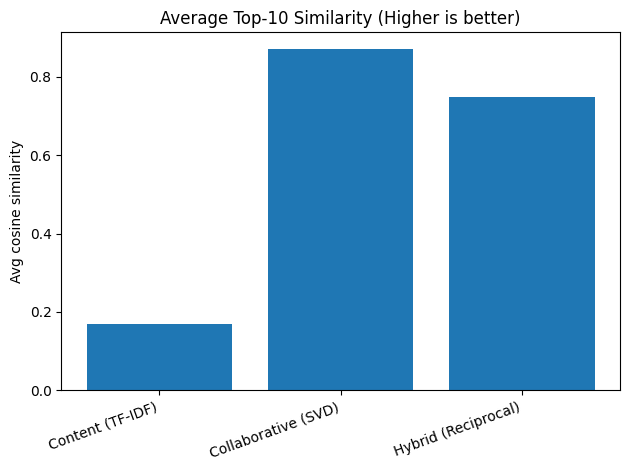

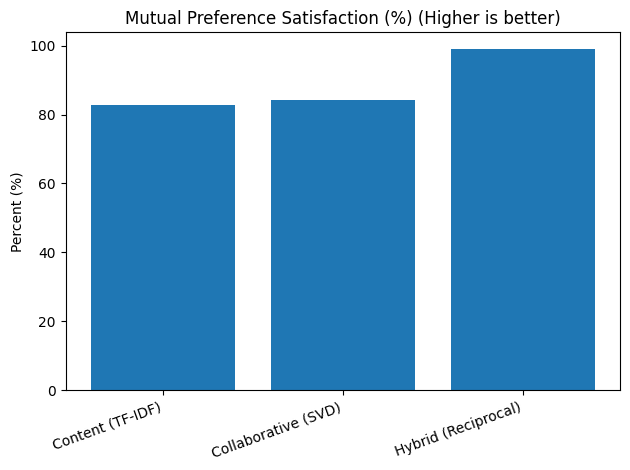

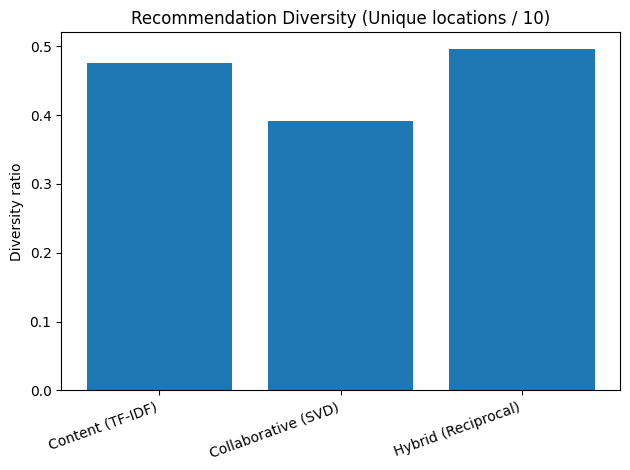

In [ ]:
# ---------- Plot 1: Bar chart of average similarity ----------
plt.figure()
plt.bar(res_df["model"], res_df["avg_similarity"])
plt.title("Average Top-10 Similarity (Higher is better)")
plt.ylabel("Avg cosine similarity")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 2: Bar chart of mutual preference satisfaction (%) ----------
plt.figure()
plt.bar(res_df["model"], res_df["mutual_satisfaction_percent"])
plt.title("Mutual Preference Satisfaction (%) (Higher is better)")
plt.ylabel("Percent (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# ---------- Plot 3: Bar chart of diversity ----------
plt.figure()
plt.bar(res_df["model"], res_df["diversity"])
plt.title("Recommendation Diversity (Unique locations / 10)")
plt.ylabel("Diversity ratio")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


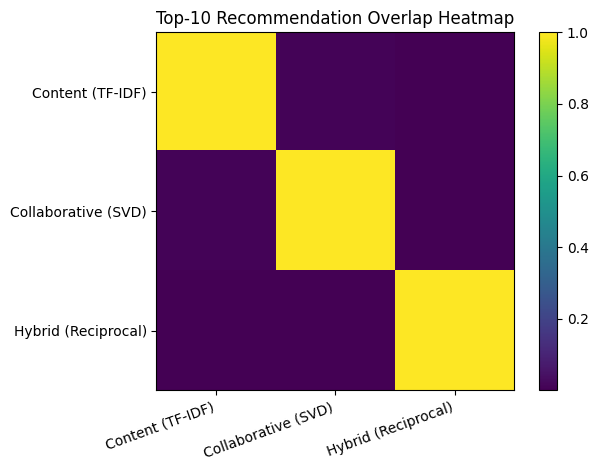

,Content (TF-IDF),Collaborative (SVD),Hybrid (Reciprocal)
Content (TF-IDF),1.000000,0.011667,0.000667
Collaborative (SVD),0.011667,1.000000,0.000333
Hybrid (Reciprocal),0.000667,0.000333,1.000000


In [ ]:
def topn_ids_for_model(indices_mat, distances_mat, user_index, top_n=10):
    recs = topn_from_knn(indices_mat, distances_mat, user_index, top_n=top_n)
    return [rid for rid, sim in recs]

def overlap_rate(list_a, list_b):
    # overlap / N
    a, b = set(list_a), set(list_b)
    return len(a & b) / max(len(a), 1)

# compute overlap on a sample of users
sample_users = np.random.RandomState(7).choice(len(df2), size=300, replace=False)

models = [
    ("Content (TF-IDF)", indices_tfidf, distances_tfidf),
    ("Collaborative (SVD)", indices_cf, distances_cf),
    ("Hybrid (Reciprocal)", indices_hybrid_base, distances_hybrid_base),
]

M = np.zeros((len(models), len(models)))

for i,(n1,ind1,dist1) in enumerate(models):
    for j,(n2,ind2,dist2) in enumerate(models):
        overlaps=[]
        for u in sample_users:
            a = topn_ids_for_model(ind1, dist1, u, top_n=10)
            b = topn_ids_for_model(ind2, dist2, u, top_n=10)
            overlaps.append(overlap_rate(a,b))
        M[i,j]=np.mean(overlaps)

plt.figure()
plt.imshow(M)
plt.title("Top-10 Recommendation Overlap Heatmap")
plt.xticks(range(len(models)), [m[0] for m in models], rotation=20, ha="right")
plt.yticks(range(len(models)), [m[0] for m in models])
plt.colorbar()
plt.tight_layout()
plt.show()

pd.DataFrame(M, index=[m[0] for m in models], columns=[m[0] for m in models])


In [ ]:
def avg_valid_matches_per_user(indices_mat, distances_mat, sample_users=200, top_n=10):
    users = np.random.RandomState(123).choice(len(df2), size=sample_users, replace=False)
    valid_counts = []

    for u in users:
        recs = topn_from_knn(indices_mat, distances_mat, u, top_n=top_n)
        valid = 0
        for rid, sim in recs:
            if preference_score(df2.iloc[u], df2.iloc[rid]) >= 4.0 and \
               preference_score(df2.iloc[rid], df2.iloc[u]) >= 4.0:
                valid += 1
        valid_counts.append(valid)

    return np.mean(valid_counts)

avg_valid = {
    "Content-Based": avg_valid_matches_per_user(indices_tfidf, distances_tfidf),
    "Collaborative": avg_valid_matches_per_user(indices_cf, distances_cf),
    "Hybrid": avg_valid_matches_per_user(indices_hybrid_base, distances_hybrid_base),
}

avg_valid


{'Content-Based': np.float64(8.245),
 'Collaborative': np.float64(8.3),
 'Hybrid': np.float64(9.835)}